<a href="https://colab.research.google.com/github/shalini2006official/Linear-regression/blob/main/kc_house_data_using_Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/kc_house_data (1).csv")

In [ ]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
df.shape

(21613, 21)

In [ ]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = df.select_dtypes(include='object')
for col in cols:
  df[col]=le.fit_transform(df[col])
print(df)

               id  date     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0      7129300520   164  221900.0         3       1.00         1180      5650   
1      6414100192   220  538000.0         3       2.25         2570      7242   
2      5631500400   290  180000.0         2       1.00          770     10000   
3      2487200875   220  604000.0         4       3.00         1960      5000   
4      1954400510   283  510000.0         3       2.00         1680      8080   
...           ...   ...       ...       ...        ...          ...       ...   
21608   263000018    19  360000.0         3       2.50         1530      1131   
21609  6600060120   288  400000.0         4       2.50         2310      5813   
21610  1523300141    52  402101.0         2       0.75         1020      1350   
21611   291310100   252  400000.0         3       2.50         1600      2388   
21612  1523300157   166  325000.0         2       0.75         1020      1076   

       floors  waterfront  

In [ ]:
from scipy.stats import zscore
numeric_cols=df.select_dtypes(include=np.number)
z_scores = np.abs(zscore(numeric_cols))
outlier = df[(z_scores>2.5).any (axis=1)]
print(outlier)

               id  date      price  bedrooms  bathrooms  sqft_living  \
1      6414100192   220   538000.0         3       2.25         2570   
5      7237550310    10  1230000.0         4       4.50         5420   
10     1736800520   327   662500.0         3       2.50         3560   
15     9297300055   259   650000.0         4       3.00         2950   
21     2524049179   116  2000000.0         3       2.75         3050   
...           ...   ...        ...       ...        ...          ...   
21599  7202300110   136   810000.0         4       3.00         3990   
21600   249000205   166  1540000.0         5       3.75         4470   
21601  5100403806   331   467000.0         3       2.50         1425   
21604  9834201367   261   429000.0         3       2.00         1490   
21608   263000018    19   360000.0         3       2.50         1530   

       sqft_lot  floors  waterfront  view  ...  grade  sqft_above  \
1          7242     2.0           0     0  ...      7        2170 

<Axes: >

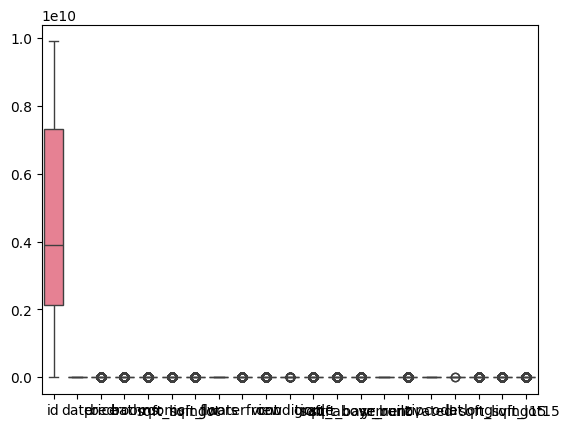

In [ ]:
sns.boxplot(df)

In [ ]:
from scipy.stats.mstats import winsorize
cols = df.select_dtypes(include=np.number)
for col in cols:
  df[col]=winsorize(df[col],limits=[0,0.10])
print(df)

               id  date     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0      7129300520   164  221900.0         3       1.00         1180      5650   
1      6414100192   220  538000.0         3       2.25         2570      7242   
2      5631500400   290  180000.0         2       1.00          770     10000   
3      2487200875   220  604000.0         4       3.00         1960      5000   
4      1954400510   283  510000.0         3       2.00         1680      8080   
...           ...   ...       ...       ...        ...          ...       ...   
21608   263000018    19  360000.0         3       2.50         1530      1131   
21609  6600060120   288  400000.0         4       2.50         2310      5813   
21610  1523300141    52  402101.0         2       0.75         1020      1350   
21611   291310100   252  400000.0         3       2.50         1600      2388   
21612  1523300157   166  325000.0         2       0.75         1020      1076   

       floors  waterfront  

<Axes: >

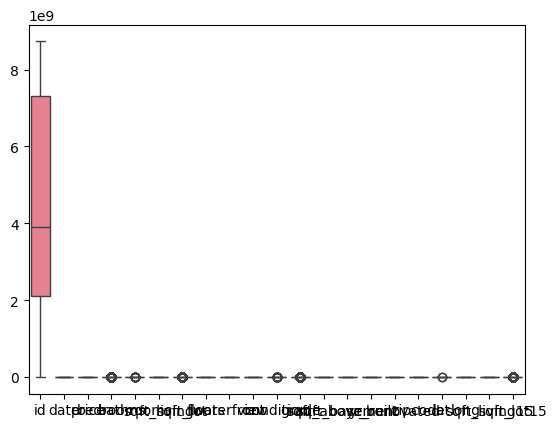

In [ ]:
sns.boxplot(df)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [ ]:
X=df.drop('price',axis=1)
y=df['price']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
print("Mean square error: ",mean_squared_error(y_pred,y_test))

Mean square error:  12161243881.539948


In [ ]:
print("r2 score: ",r2_score(y_pred,y_test)) #value should between 0 to 1

r2 score:  0.6347143346697298


In [ ]:
print("mean_absolute_error ",mean_absolute_error(y_pred,y_test))

mean_absolute_error  86528.1871513134


In [ ]:
print("root_mean_squared_error: ",root_mean_squared_error(y_pred,y_test))

root_mean_squared_error:  110278.02991321502
